In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Test the imports
print("Dependencies imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

Dependencies imported successfully!
pandas version: 2.2.3
numpy version: 2.2.3


In [ ]:
# Data Loading Cell - Load all country data once
import pandas as pd
import numpy as np

# Load all 5 countries' clean data
countries_data = {
    'Ethiopia': pd.read_csv('../data/ethiopia_clean.csv'),
    'Nigeria': pd.read_csv('../data/nigeria_clean.csv'),
    'Sudan': pd.read_csv('../data/sudan_clean.csv'),
    'Tanzania': pd.read_csv('../data/tanzania_clean.csv'),
    'Kenya': pd.read_csv('../data/kenya_clean.csv')
}

# Add country column to each dataset
for country, df in countries_data.items():
    df['Country'] = country

# Combine all data into a single DataFrame
all_countries = pd.concat(countries_data.values(), ignore_index=True)

# Add date column for time series analysis
all_countries['Date'] = pd.to_datetime(all_countries['YEAR'].astype(str) + all_countries['DOY'].astype(str), format='%Y%j')

# Filter for 2015-2026 data (adjust as needed)
all_countries_filtered = all_countries[(all_countries['YEAR'] >= 2015) & (all_countries['YEAR'] <= 2026)]

print(f"Loaded data for {len(countries_data)} countries")
print(f"Total observations: {len(all_countries):,}")
print(f"Filtered observations (2015-2026): {len(all_countries_filtered):,}")
print(f"Date range: {all_countries['Date'].min()} to {all_countries['Date'].max()}")
print("\nCountries available:", list(countries_data.keys()))

# Display sample of combined data
print("\nSample data:")
display(all_countries.head())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
1,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
2,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
3,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia
4,2015,6,14.26,23.45,7.44,16.01,0.0,58.20,1.70,2.75,77.07,6.95,Ethiopia


### Temperature Trend Comparison

AttributeError: module 'matplotlib.pyplot' has no attribute 'DateFormatter'

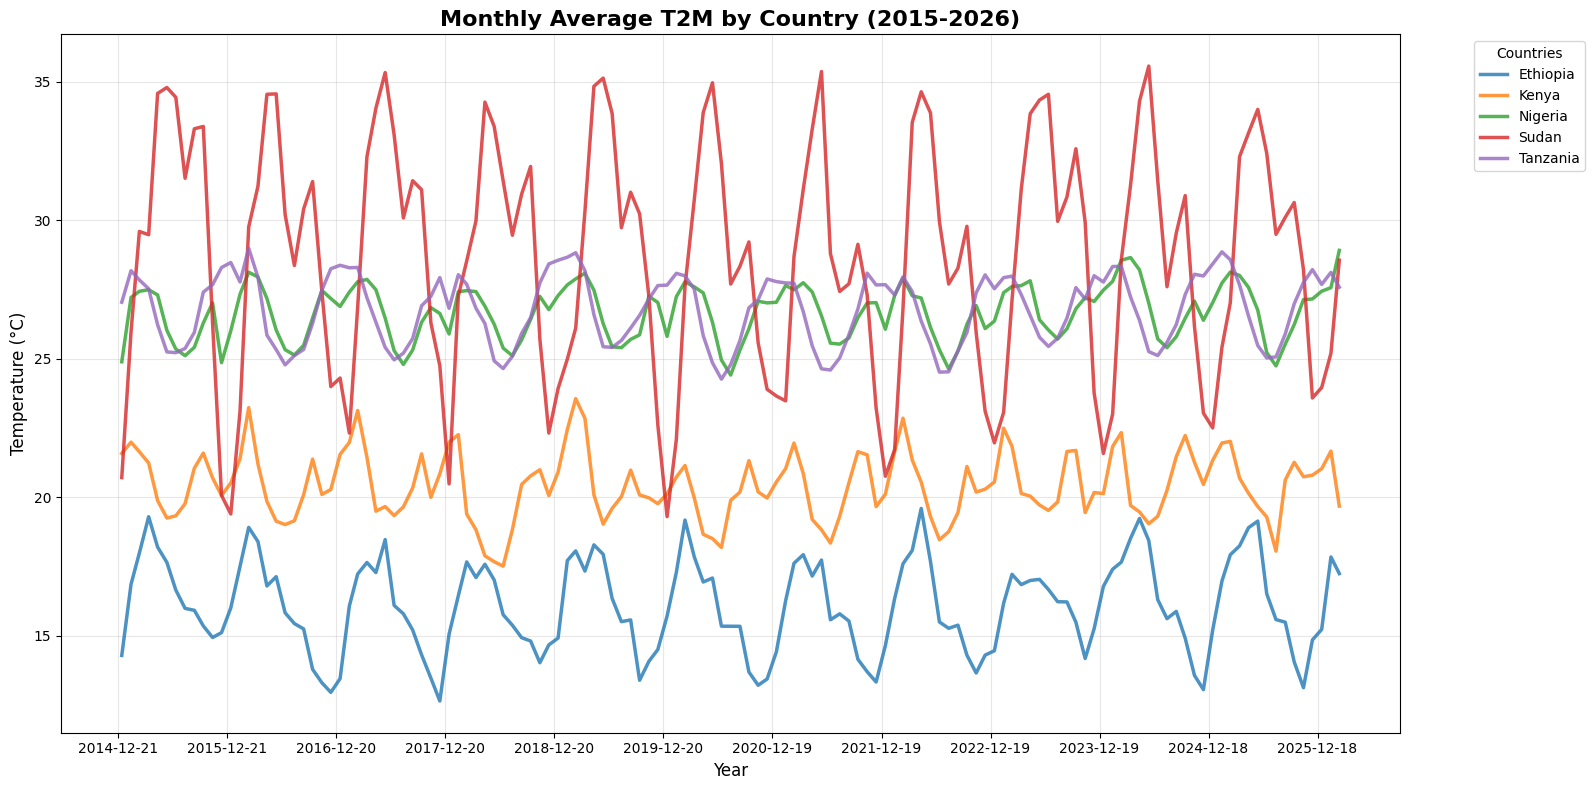

In [ ]:
# Monthly Average T2M Line Chart (using pre-loaded data)

# Create month column for monthly averaging
all_countries_filtered['YearMonth'] = all_countries_filtered['Date'].dt.to_period('M')

# Calculate monthly averages for each country
monthly_avg = all_countries_filtered.groupby(['Country', 'YearMonth'])['T2M'].mean().reset_index()
monthly_avg['Date'] = monthly_avg['YearMonth'].dt.to_timestamp()

# Create single line chart
plt.figure(figsize=(16, 8))
countries = monthly_avg['Country'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, country in enumerate(countries):
    country_data = monthly_avg[monthly_avg['Country'] == country]
    plt.plot(country_data['Date'], country_data['T2M'], 
             label=country, color=colors[i], linewidth=2.5, alpha=0.8)

plt.title('Monthly Average T2M by Country (2015-2026)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(title='Countries', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Format x-axis to show years
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(365))  # Show yearly ticks
plt.gca().xaxis.set_major_formatter(plt.DateFormatter('%Y'))

plt.show()

In [11]:
# Summary Statistics Table (using pre-loaded data)

# Create summary statistics table for T2M across countries
summary_stats = all_countries_filtered.groupby('Country')['T2M'].agg([
    'mean',
    'median', 
    'std',
    'min',
    'max',
    'count'
]).round(2)

# Add temperature range
summary_stats['Range'] = summary_stats['max'] - summary_stats['min']

# Reorder columns for better readability
summary_stats = summary_stats[['mean', 'median', 'std', 'min', 'max', 'Range', 'count']]

# Rename columns for better presentation
summary_stats.columns = ['Mean (°C)', 'Median (°C)', 'Std Dev (°C)', 'Min (°C)', 'Max (°C)', 'Range (°C)', 'Observations']

# Display the summary table
print("T2M Summary Statistics by Country (2015-2026)")
print("=" * 80)
print(summary_stats)

# Key insights
print("\nKey Insights:")
print(f"Highest mean temperature: {summary_stats['Mean (°C)'].idxmax()} ({summary_stats['Mean (°C)'].max():.2f}°C)")
print(f"Lowest mean temperature: {summary_stats['Mean (°C)'].idxmin()} ({summary_stats['Mean (°C)'].min():.2f}°C)")
print(f"Highest temperature variability: {summary_stats['Std Dev (°C)'].idxmax()} ({summary_stats['Std Dev (°C)'].max():.2f}°C)")
print(f"Largest temperature range: {summary_stats['Range (°C)'].idxmax()} ({summary_stats['Range (°C)'].max():.2f}°C)")

T2M Summary Statistics by Country (2015-2026)
          Mean (°C)  Median (°C)  Std Dev (°C)  Min (°C)  Max (°C)  \
Country                                                              
Ethiopia      16.07        16.04          1.90     10.03     21.53   
Kenya         20.43        20.36          1.44     15.26     25.40   
Nigeria       26.66        26.82          1.12     21.12     29.29   
Sudan         28.76        29.16          4.68     13.18     37.99   
Tanzania      26.80        26.99          1.33     22.68     29.97   

          Range (°C)  Observations  
Country                             
Ethiopia       11.50          4107  
Kenya          10.14          4107  
Nigeria         8.17          4107  
Sudan          24.81          4107  
Tanzania        7.29          4107  

Key Insights:
Highest mean temperature: Sudan (28.76°C)
Lowest mean temperature: Ethiopia (16.07°C)
Highest temperature variability: Sudan (4.68°C)
Largest temperature range: Sudan (24.81°C)


Precipitation Variability Comparison

C:\Users\PC\AppData\Local\Temp\ipykernel_12292\619597339.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_countries_filtered, x='Country', y='PRECTOTCORR',


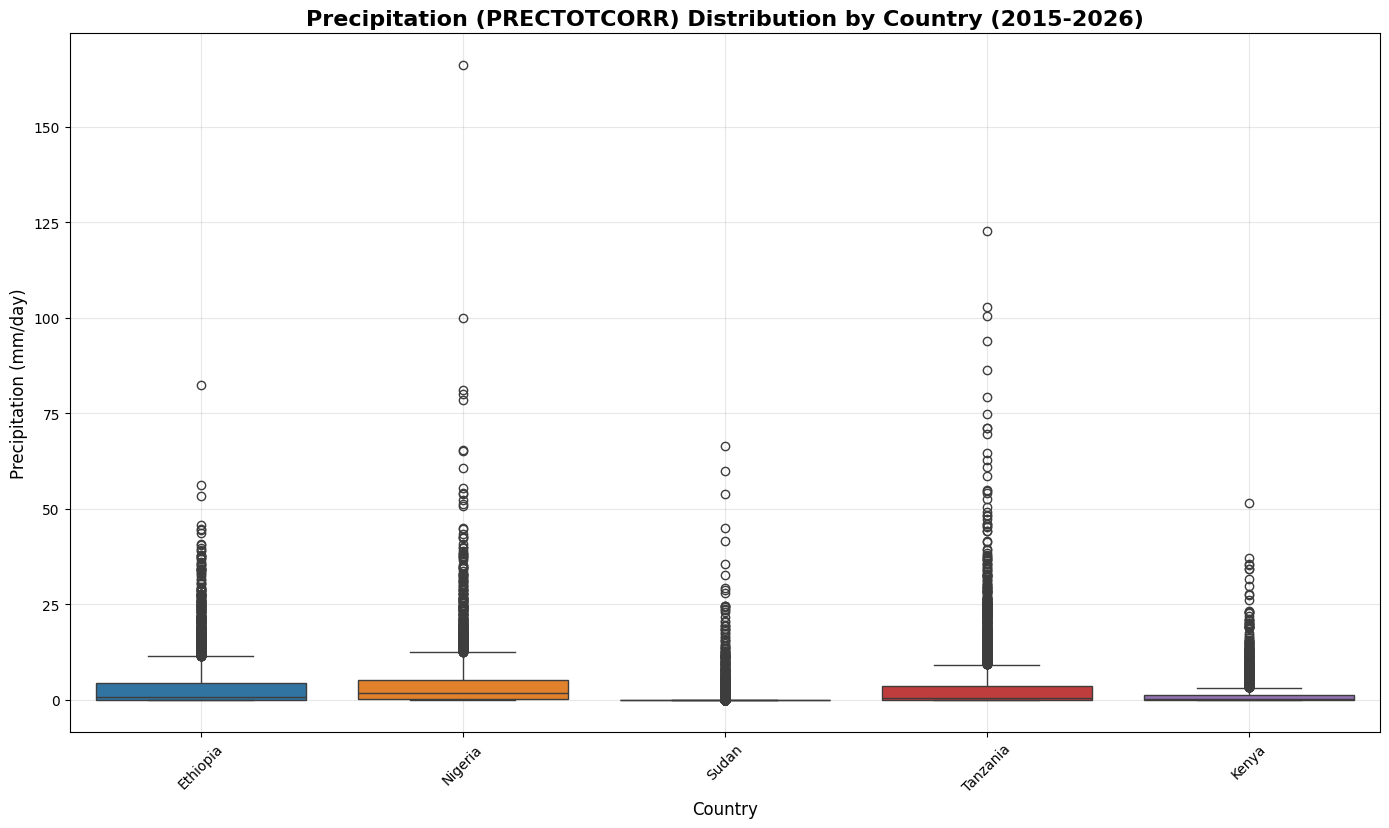

Precipitation (PRECTOTCORR) Summary Statistics by Country (2015-2026)
           mean  median    std  min     max  count
Country                                           
Ethiopia  3.635    0.82  6.290  0.0   82.30   4107
Kenya     1.469    0.38  3.181  0.0   51.65   4107
Nigeria   4.215    1.84  7.267  0.0  166.10   4107
Sudan     0.644    0.00  3.058  0.0   66.49   4107
Tanzania  3.739    0.64  8.005  0.0  122.65   4107

Precipitation Insights:
Highest mean precipitation: Nigeria (4.215 mm/day)
Lowest mean precipitation: Sudan (0.644 mm/day)
Highest precipitation variability: Tanzania (8.005 mm/day)


In [32]:
# Side-by-side Boxplots of PRECTOTCORR (Precipitation) for All Countries

plt.figure(figsize=(14, 8))

# Create boxplot using seaborn for better styling
sns.boxplot(data=all_countries_filtered, x='Country', y='PRECTOTCORR', 
            palette=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

plt.title('Precipitation (PRECTOTCORR) Distribution by Country (2015-2026)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Precipitation (mm/day)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Rotate x-axis labels if needed for better readability
plt.xticks(rotation=45)

plt.show()

# Summary statistics for precipitation
precip_stats = all_countries_filtered.groupby('Country')['PRECTOTCORR'].agg([
    'mean', 'median', 'std', 'min', 'max', 'count'
]).round(3)

print("Precipitation (PRECTOTCORR) Summary Statistics by Country (2015-2026)")
print("=" * 80)
print(precip_stats)

# Key insights for precipitation
print("\nPrecipitation Insights:")
print(f"Highest mean precipitation: {precip_stats['mean'].idxmax()} ({precip_stats['mean'].max():.3f} mm/day)")
print(f"Lowest mean precipitation: {precip_stats['mean'].idxmin()} ({precip_stats['mean'].min():.3f} mm/day)")
print(f"Highest precipitation variability: {precip_stats['std'].idxmax()} ({precip_stats['std'].max():.3f} mm/day)")


In [30]:
# Summary Table: PRECTOTCORR Statistics by Country

# Create summary statistics table for PRECTOTCORR across countries
precip_summary = all_countries_filtered.groupby('Country')['PRECTOTCORR'].agg([
    'mean',
    'median', 
    'std'
]).round(3)

# Rename columns for better presentation
precip_summary.columns = ['Mean (mm/day)', 'Median (mm/day)', 'Std Dev (mm/day)']

# Display the summary table
print("\n" + "="*60)
print("PRECTOTCORR Summary Statistics by Country (2015-2026)")
print("=" * 60)
print(precip_summary)

# Key insights
print("\nKey Insights:")
print(f"Highest mean precipitation: {precip_summary['Mean (mm/day)'].idxmax()} ({precip_summary['Mean (mm/day)'].max():.3f} mm/day)")
print(f"Lowest mean precipitation: {precip_summary['Mean (mm/day)'].idxmin()} ({precip_summary['Mean (mm/day)'].min():.3f} mm/day)")
print(f"Highest precipitation variability: {precip_summary['Std Dev (mm/day)'].idxmax()} ({precip_summary['Std Dev (mm/day)'].max():.3f} mm/day)")
print(f"Lowest precipitation variability: {precip_summary['Std Dev (mm/day)'].idxmin()} ({precip_summary['Std Dev (mm/day)'].min():.3f} mm/day)")

# Additional analysis: precipitation patterns
print(f"\nPrecipitation Patterns:")
print(f"Most consistent rainfall: {precip_summary['Std Dev (mm/day)'].idxmin()} (std dev: {precip_summary['Std Dev (mm/day)'].min():.3f})")
print(f"Most variable rainfall: {precip_summary['Std Dev (mm/day)'].idxmax()} (std dev: {precip_summary['Std Dev (mm/day)'].max():.3f})")

# Calculate coefficient of variation for relative comparison
precip_summary['CV (%)'] = (precip_summary['Std Dev (mm/day)'] / precip_summary['Mean (mm/day)'] * 100).round(1)
print(f"\nCoefficient of Variation (CV %):")
print(precip_summary['CV (%)'].sort_values())


PRECTOTCORR Summary Statistics by Country (2015-2026)
          Mean (mm/day)  Median (mm/day)  Std Dev (mm/day)
Country                                                   
Ethiopia          3.635             0.82             6.290
Kenya             1.469             0.38             3.181
Nigeria           4.215             1.84             7.267
Sudan             0.644             0.00             3.058
Tanzania          3.739             0.64             8.005

Key Insights:
Highest mean precipitation: Nigeria (4.215 mm/day)
Lowest mean precipitation: Sudan (0.644 mm/day)
Highest precipitation variability: Tanzania (8.005 mm/day)
Lowest precipitation variability: Sudan (3.058 mm/day)

Precipitation Patterns:
Most consistent rainfall: Sudan (std dev: 3.058)
Most variable rainfall: Tanzania (std dev: 8.005)

Coefficient of Variation (CV %):
Country
Nigeria     172.4
Ethiopia    173.0
Tanzania    214.1
Kenya       216.5
Sudan       474.8
Name: CV (%), dtype: float64


Extreme Event Frequency

Extreme Heat Days (T2M_MAX > 35°C) by Country and Year
Country  Sudan
YEAR          
2015       279
2016       252
2017       266
2018       248
2019       251
2020       195
2021       212
2022       202
2023       262
2024       223
2025       260
2026        43

Extreme Heat Summary Statistics (2015-2026)
         Avg Days/Year  Max Days (Year)  Min Days (Year)  Std Dev  \
Country                                                             
Sudan            224.4              279               43     63.1   

         Total Extreme Days  
Country                      
Sudan                  2693  

Extreme Heat Insights:
Country with most extreme heat days (total): Sudan (2693 days)
Country with fewest extreme heat days (total): Sudan (2693 days)
Country with highest average per year: Sudan (224.4 days/year)
Country with most extreme heat in a single year: Sudan (279 days)


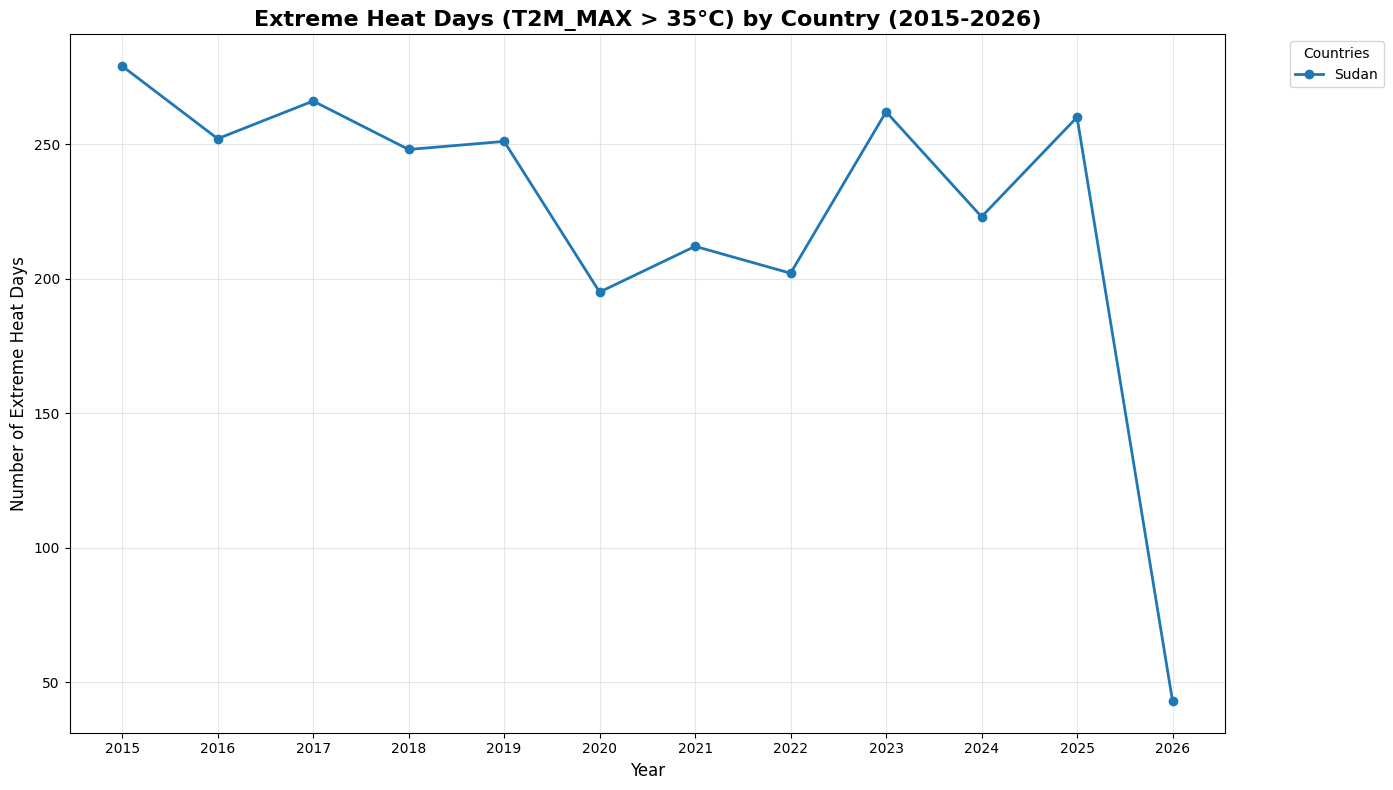

In [33]:
# Extreme Heat Event Frequency: Days per year with T2M_MAX > 35°C

# Filter for extreme heat days (T2M_MAX > 35°C)
extreme_heat_days = all_countries_filtered[all_countries_filtered['T2M_MAX'] > 35]

# Count extreme heat days by country and year
extreme_heat_counts = extreme_heat_days.groupby(['Country', 'YEAR']).size().reset_index(name='Extreme_Heat_Days')

# Create a pivot table for better visualization
extreme_heat_pivot = extreme_heat_counts.pivot(index='YEAR', columns='Country', values='Extreme_Heat_Days').fillna(0)

print("Extreme Heat Days (T2M_MAX > 35°C) by Country and Year")
print("=" * 60)
print(extreme_heat_pivot)

# Calculate summary statistics for extreme heat days
extreme_heat_summary = extreme_heat_counts.groupby('Country')['Extreme_Heat_Days'].agg([
    'mean',
    'max', 
    'min',
    'std',
    'sum'
]).round(1)

# Rename columns
extreme_heat_summary.columns = ['Avg Days/Year', 'Max Days (Year)', 'Min Days (Year)', 'Std Dev', 'Total Extreme Days']

print("\nExtreme Heat Summary Statistics (2015-2026)")
print("=" * 60)
print(extreme_heat_summary)

# Key insights
print("\nExtreme Heat Insights:")
print(f"Country with most extreme heat days (total): {extreme_heat_summary['Total Extreme Days'].idxmax()} ({extreme_heat_summary['Total Extreme Days'].max():.0f} days)")
print(f"Country with fewest extreme heat days (total): {extreme_heat_summary['Total Extreme Days'].idxmin()} ({extreme_heat_summary['Total Extreme Days'].min():.0f} days)")
print(f"Country with highest average per year: {extreme_heat_summary['Avg Days/Year'].idxmax()} ({extreme_heat_summary['Avg Days/Year'].max():.1f} days/year)")
print(f"Country with most extreme heat in a single year: {extreme_heat_summary['Max Days (Year)'].idxmax()} ({extreme_heat_summary['Max Days (Year)'].max():.0f} days)")

# Plot extreme heat days over time
plt.figure(figsize=(14, 8))
for country in extreme_heat_pivot.columns:
    plt.plot(extreme_heat_pivot.index, extreme_heat_pivot[country], 
             marker='o', linewidth=2, label=country)

plt.title('Extreme Heat Days (T2M_MAX > 35°C) by Country (2015-2026)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Extreme Heat Days', fontsize=12)
plt.legend(title='Countries', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(extreme_heat_pivot.index)
plt.tight_layout()
plt.show()

Maximum Consecutive Dry Days (PRECTOTCORR < 1 mm) by Country and Year
Country  Ethiopia  Kenya  Nigeria  Sudan  Tanzania
Year                                              
2015           25     56       39    160        51
2016           35     43       43    126        34
2017           43     38       35    115        34
2018           35     25       36    149        60
2019           46     44       15    154        51
2020           39     22       61    166        35
2021           28     54       35    128        59
2022           29     48       41    158        48
2023           55     45       30    161        34
2024           38     42       50    162        28
2025           61     39       28    143        26
2026           21     37       16     90        23

Consecutive Dry Days Summary Statistics (2015-2026)
          Avg Max Consecutive  Max Consecutive (Year)  Min Consecutive (Year)  \
Country                                                                         
E

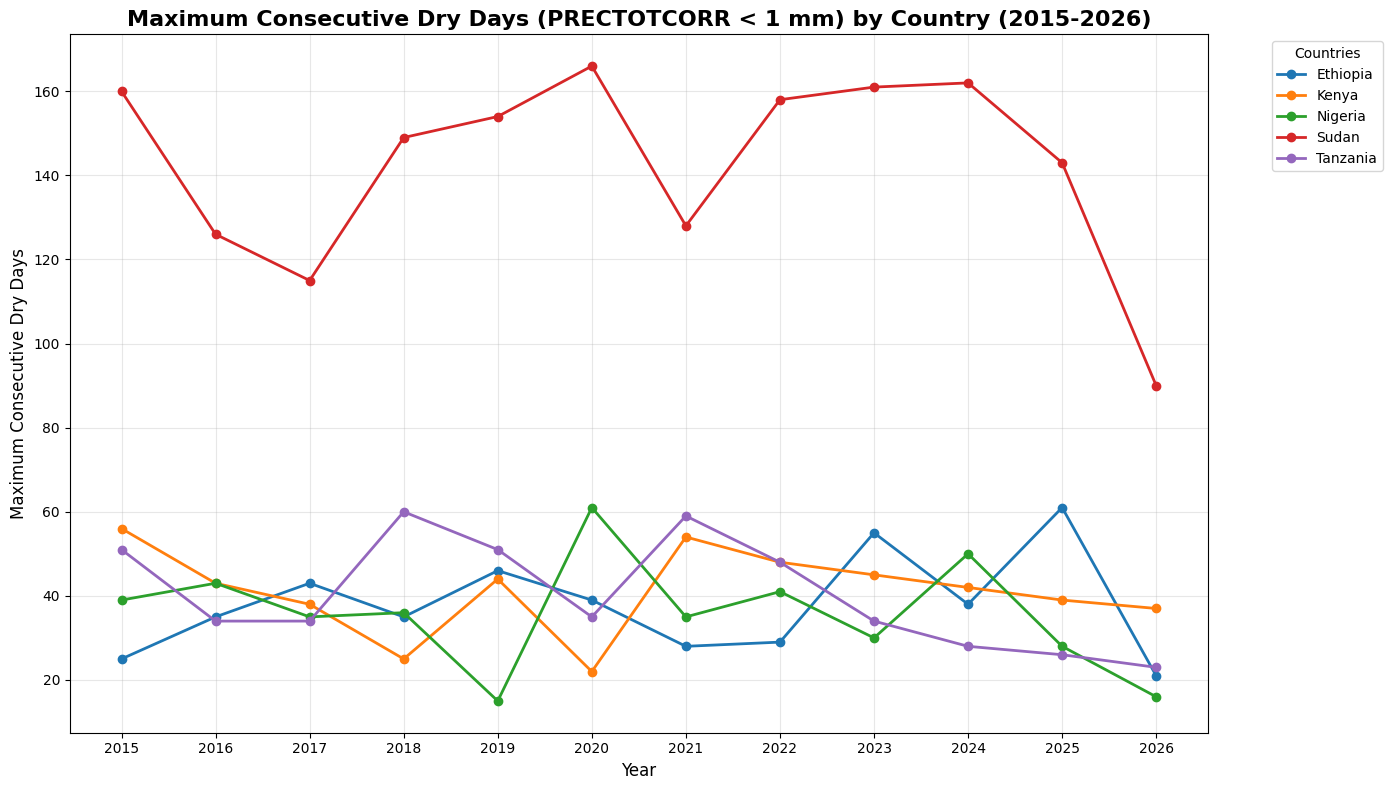


Dry Spell Distribution Analysis:

Ethiopia:
  Years with dry spells > 30 days: 8
  Years with dry spells > 60 days: 1
  Years with dry spells > 90 days: 0

Nigeria:
  Years with dry spells > 30 days: 8
  Years with dry spells > 60 days: 1
  Years with dry spells > 90 days: 0

Sudan:
  Years with dry spells > 30 days: 12
  Years with dry spells > 60 days: 12
  Years with dry spells > 90 days: 11

Tanzania:
  Years with dry spells > 30 days: 9
  Years with dry spells > 60 days: 0
  Years with dry spells > 90 days: 0

Kenya:
  Years with dry spells > 30 days: 10
  Years with dry spells > 60 days: 0
  Years with dry spells > 90 days: 0


In [34]:
# Consecutive Dry Days Analysis: Days where PRECTOTCORR < 1 mm

def count_consecutive_dry_days(group):
    """Count consecutive dry days (PRECTOTCORR < 1 mm) for a group"""
    dry_days = group['PRECTOTCORR'] < 1
    consecutive_counts = []
    current_count = 0
    
    for is_dry in dry_days:
        if is_dry:
            current_count += 1
        else:
            if current_count > 0:
                consecutive_counts.append(current_count)
                current_count = 0
    
    # Add the last count if the period ends with dry days
    if current_count > 0:
        consecutive_counts.append(current_count)
    
    return consecutive_counts

# Group by country and year
consecutive_dry_results = []

for country in all_countries_filtered['Country'].unique():
    country_data = all_countries_filtered[all_countries_filtered['Country'] == country]
    
    for year in country_data['YEAR'].unique():
        year_data = country_data[country_data['YEAR'] == year].sort_values('DOY')
        
        # Count consecutive dry days
        consecutive_counts = count_consecutive_dry_days(year_data)
        
        # Calculate statistics
        if consecutive_counts:
            max_consecutive = max(consecutive_counts)
            avg_consecutive = sum(consecutive_counts) / len(consecutive_counts)
            total_dry_spells = len(consecutive_counts)
            total_dry_days = sum(consecutive_counts)
        else:
            max_consecutive = 0
            avg_consecutive = 0
            total_dry_spells = 0
            total_dry_days = 0
        
        consecutive_dry_results.append({
            'Country': country,
            'Year': year,
            'Max_Consecutive_Dry_Days': max_consecutive,
            'Avg_Consecutive_Dry_Days': round(avg_consecutive, 1),
            'Total_Dry_Spells': total_dry_spells,
            'Total_Dry_Days': total_dry_days
        })

# Create DataFrame
dry_days_df = pd.DataFrame(consecutive_dry_results)

# Create pivot table for maximum consecutive dry days
max_consecutive_pivot = dry_days_df.pivot(index='Year', columns='Country', values='Max_Consecutive_Dry_Days').fillna(0)

print("Maximum Consecutive Dry Days (PRECTOTCORR < 1 mm) by Country and Year")
print("=" * 70)
print(max_consecutive_pivot)

# Summary statistics for consecutive dry days
dry_summary = dry_days_df.groupby('Country').agg({
    'Max_Consecutive_Dry_Days': ['mean', 'max', 'min'],
    'Avg_Consecutive_Dry_Days': 'mean',
    'Total_Dry_Spells': 'sum',
    'Total_Dry_Days': 'sum'
}).round(1)

# Flatten column names
dry_summary.columns = ['Avg Max Consecutive', 'Max Consecutive (Year)', 'Min Consecutive (Year)', 
                      'Overall Avg Consecutive', 'Total Dry Spells', 'Total Dry Days']

print("\nConsecutive Dry Days Summary Statistics (2015-2026)")
print("=" * 70)
print(dry_summary)

# Key insights
print("\nConsecutive Dry Days Insights:")
print(f"Highest average max consecutive dry days: {dry_summary['Avg Max Consecutive'].idxmax()} ({dry_summary['Avg Max Consecutive'].max():.1f} days)")
print(f"Longest dry spell recorded: {dry_summary['Max Consecutive (Year)'].idxmax()} ({dry_summary['Max Consecutive (Year)'].max():.0f} days)")
print(f"Most total dry days: {dry_summary['Total Dry Days'].idxmax()} ({dry_summary['Total Dry Days'].max():.0f} days)")
print(f"Most dry spells: {dry_summary['Total Dry Spells'].idxmax()} ({dry_summary['Total Dry Spells'].max():.0f} spells)")

# Plot maximum consecutive dry days over time
plt.figure(figsize=(14, 8))
for country in max_consecutive_pivot.columns:
    plt.plot(max_consecutive_pivot.index, max_consecutive_pivot[country], 
             marker='o', linewidth=2, label=country)

plt.title('Maximum Consecutive Dry Days (PRECTOTCORR < 1 mm) by Country (2015-2026)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Maximum Consecutive Dry Days', fontsize=12)
plt.legend(title='Countries', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(max_consecutive_pivot.index)
plt.tight_layout()
plt.show()

# Additional analysis: Dry spell distribution
print("\nDry Spell Distribution Analysis:")
for country in dry_days_df['Country'].unique():
    country_data = dry_days_df[dry_days_df['Country'] == country]
    print(f"\n{country}:")
    print(f"  Years with dry spells > 30 days: {len(country_data[country_data['Max_Consecutive_Dry_Days'] > 30])}")
    print(f"  Years with dry spells > 60 days: {len(country_data[country_data['Max_Consecutive_Dry_Days'] > 60])}")
    print(f"  Years with dry spells > 90 days: {len(country_data[country_data['Max_Consecutive_Dry_Days'] > 90])}")

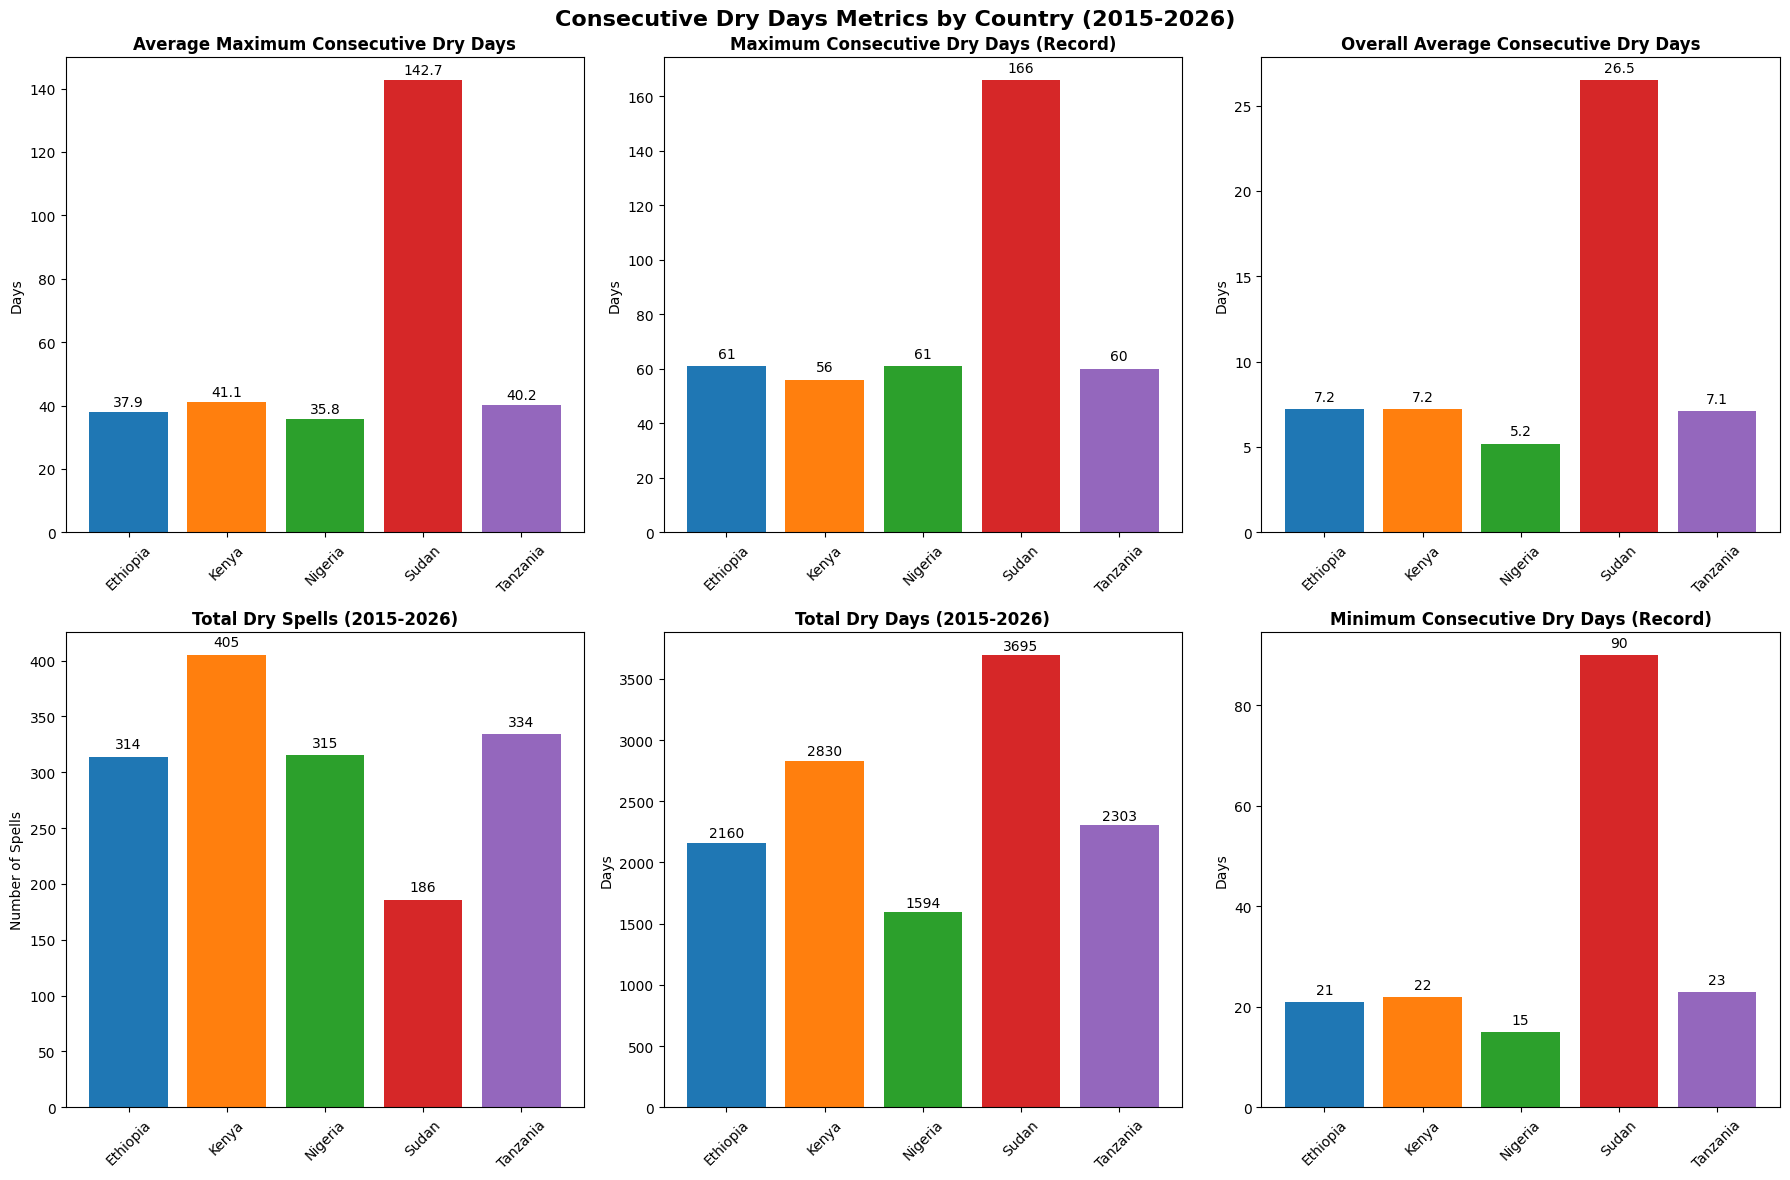

Consecutive Dry Days - Key Metrics Summary by Country
          Avg Max Consecutive  Max Consecutive (Year)  \
Country                                                 
Ethiopia                 37.9                      61   
Kenya                    41.1                      56   
Nigeria                  35.8                      61   
Sudan                   142.7                     166   
Tanzania                 40.2                      60   

          Overall Avg Consecutive  Total Dry Spells  Total Dry Days  
Country                                                              
Ethiopia                      7.2               314            2160  
Kenya                         7.2               405            2830  
Nigeria                       5.2               315            1594  
Sudan                        26.5               186            3695  
Tanzania                      7.1               334            2303  

Key Insights from Bar Charts:
1. SUDAN shows extreme dr

In [35]:
# Bar Charts for Consecutive Dry Days Metrics - One Chart Per Metric, Colored by Country

# Set up the figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Consecutive Dry Days Metrics by Country (2015-2026)', fontsize=16, fontweight='bold')

# Define colors for each country
colors = {
    'Ethiopia': '#1f77b4',
    'Kenya': '#ff7f0e', 
    'Nigeria': '#2ca02c',
    'Sudan': '#d62728',
    'Tanzania': '#9467bd'
}

# 1. Average Maximum Consecutive Dry Days
ax1 = axes[0, 0]
avg_max_data = dry_summary['Avg Max Consecutive']
bars1 = ax1.bar(avg_max_data.index, avg_max_data.values, 
                color=[colors[country] for country in avg_max_data.index])
ax1.set_title('Average Maximum Consecutive Dry Days', fontsize=12, fontweight='bold')
ax1.set_ylabel('Days')
ax1.tick_params(axis='x', rotation=45)
# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom')

# 2. Maximum Consecutive Dry Days (Overall Maximum)
ax2 = axes[0, 1]
max_data = dry_summary['Max Consecutive (Year)']
bars2 = ax2.bar(max_data.index, max_data.values,
                color=[colors[country] for country in max_data.index])
ax2.set_title('Maximum Consecutive Dry Days (Record)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Days')
ax2.tick_params(axis='x', rotation=45)
# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{height:.0f}', ha='center', va='bottom')

# 3. Overall Average Consecutive Dry Days
ax3 = axes[0, 2]
avg_data = dry_summary['Overall Avg Consecutive']
bars3 = ax3.bar(avg_data.index, avg_data.values,
                color=[colors[country] for country in avg_data.index])
ax3.set_title('Overall Average Consecutive Dry Days', fontsize=12, fontweight='bold')
ax3.set_ylabel('Days')
ax3.tick_params(axis='x', rotation=45)
# Add value labels on bars
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height:.1f}', ha='center', va='bottom')

# 4. Total Dry Spells
ax4 = axes[1, 0]
spells_data = dry_summary['Total Dry Spells']
bars4 = ax4.bar(spells_data.index, spells_data.values,
                color=[colors[country] for country in spells_data.index])
ax4.set_title('Total Dry Spells (2015-2026)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Number of Spells')
ax4.tick_params(axis='x', rotation=45)
# Add value labels on bars
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height:.0f}', ha='center', va='bottom')

# 5. Total Dry Days
ax5 = axes[1, 1]
total_days_data = dry_summary['Total Dry Days']
bars5 = ax5.bar(total_days_data.index, total_days_data.values,
                color=[colors[country] for country in total_days_data.index])
ax5.set_title('Total Dry Days (2015-2026)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Days')
ax5.tick_params(axis='x', rotation=45)
# Add value labels on bars
for bar in bars5:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{height:.0f}', ha='center', va='bottom')

# 6. Minimum Consecutive Dry Days
ax6 = axes[1, 2]
min_data = dry_summary['Min Consecutive (Year)']
bars6 = ax6.bar(min_data.index, min_data.values,
                color=[colors[country] for country in min_data.index])
ax6.set_title('Minimum Consecutive Dry Days (Record)', fontsize=12, fontweight='bold')
ax6.set_ylabel('Days')
ax6.tick_params(axis='x', rotation=45)
# Add value labels on bars
for bar in bars6:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.0f}', ha='center', va='bottom')

# Remove the empty subplot if any
if len(axes.flat) > 6:
    fig.delaxes(axes.flat[6])

plt.tight_layout()
plt.show()

# Create a summary table with the key metrics for easy reference
print("Consecutive Dry Days - Key Metrics Summary by Country")
print("=" * 80)
summary_table = dry_summary[['Avg Max Consecutive', 'Max Consecutive (Year)', 
                            'Overall Avg Consecutive', 'Total Dry Spells', 'Total Dry Days']]
print(summary_table)

# Key insights from the bar charts
print("\nKey Insights from Bar Charts:")
print("=" * 50)
print("1. SUDAN shows extreme dryness across all metrics:")
print(f"   - Average max consecutive: {dry_summary.loc['Sudan', 'Avg Max Consecutive']:.1f} days (highest)")
print(f"   - Record dry spell: {dry_summary.loc['Sudan', 'Max Consecutive (Year)']:.0f} days (longest)")
print(f"   - Total dry days: {dry_summary.loc['Sudan', 'Total Dry Days']:.0f} days (most)")

print(f"\n2. KENYA has the most frequent dry spells: {dry_summary.loc['Kenya', 'Total Dry Spells']:.0f} spells")
print("   But shorter durations compared to Sudan")

print(f"\n3. NIGERIA shows moderate dryness:")
print(f"   - Average max consecutive: {dry_summary.loc['Nigeria', 'Avg Max Consecutive']:.1f} days")
print(f"   - Most consistent (lowest variability in dry spell lengths)")

print(f"\n4. ETHIOPIA and TANZANIA show similar patterns:")
print(f"   - Ethiopia: {dry_summary.loc['Ethiopia', 'Avg Max Consecutive']:.1f} days avg max")
print(f"   - Tanzania: {dry_summary.loc['Tanzania', 'Avg Max Consecutive']:.1f} days avg max")

Statistical Testing 

CLIMATE VULNERABILITY RANKING TABLE
Rank | Country    | Temp (°C) | Temp Var | Precip (mm/d) | Precip Var | Max Dry Days | Total Dry | Temp Vul | Prec Vul | Drought Vul | Overall Score
------------------------------------------------------------------------------------------------------------------------
   1 | Sudan     |    28.76 |    4.68 |        0.64 |     4.748 |       142.7 |      3695 |   0.475 |   1.211 |      0.645 |       2.330
   2 | Kenya     |    20.43 |    1.44 |        1.47 |     2.166 |        41.1 |      2830 |   0.262 |   0.645 |      0.221 |       1.128
   3 | Tanzania  |    26.80 |    1.33 |        3.74 |     2.141 |        40.2 |      2303 |   0.321 |   0.504 |      0.207 |       1.032
   4 | Nigeria   |    26.66 |    1.12 |        4.21 |     1.724 |        35.8 |      1594 |   0.312 |   0.392 |      0.175 |       0.878
   5 | Ethiopia  |    16.07 |    1.90 |        3.63 |     1.730 |        37.9 |      2160 |   0.237 |   0.428 |      0.195 |       0.859


<Figure size 1400x1000 with 0 Axes>

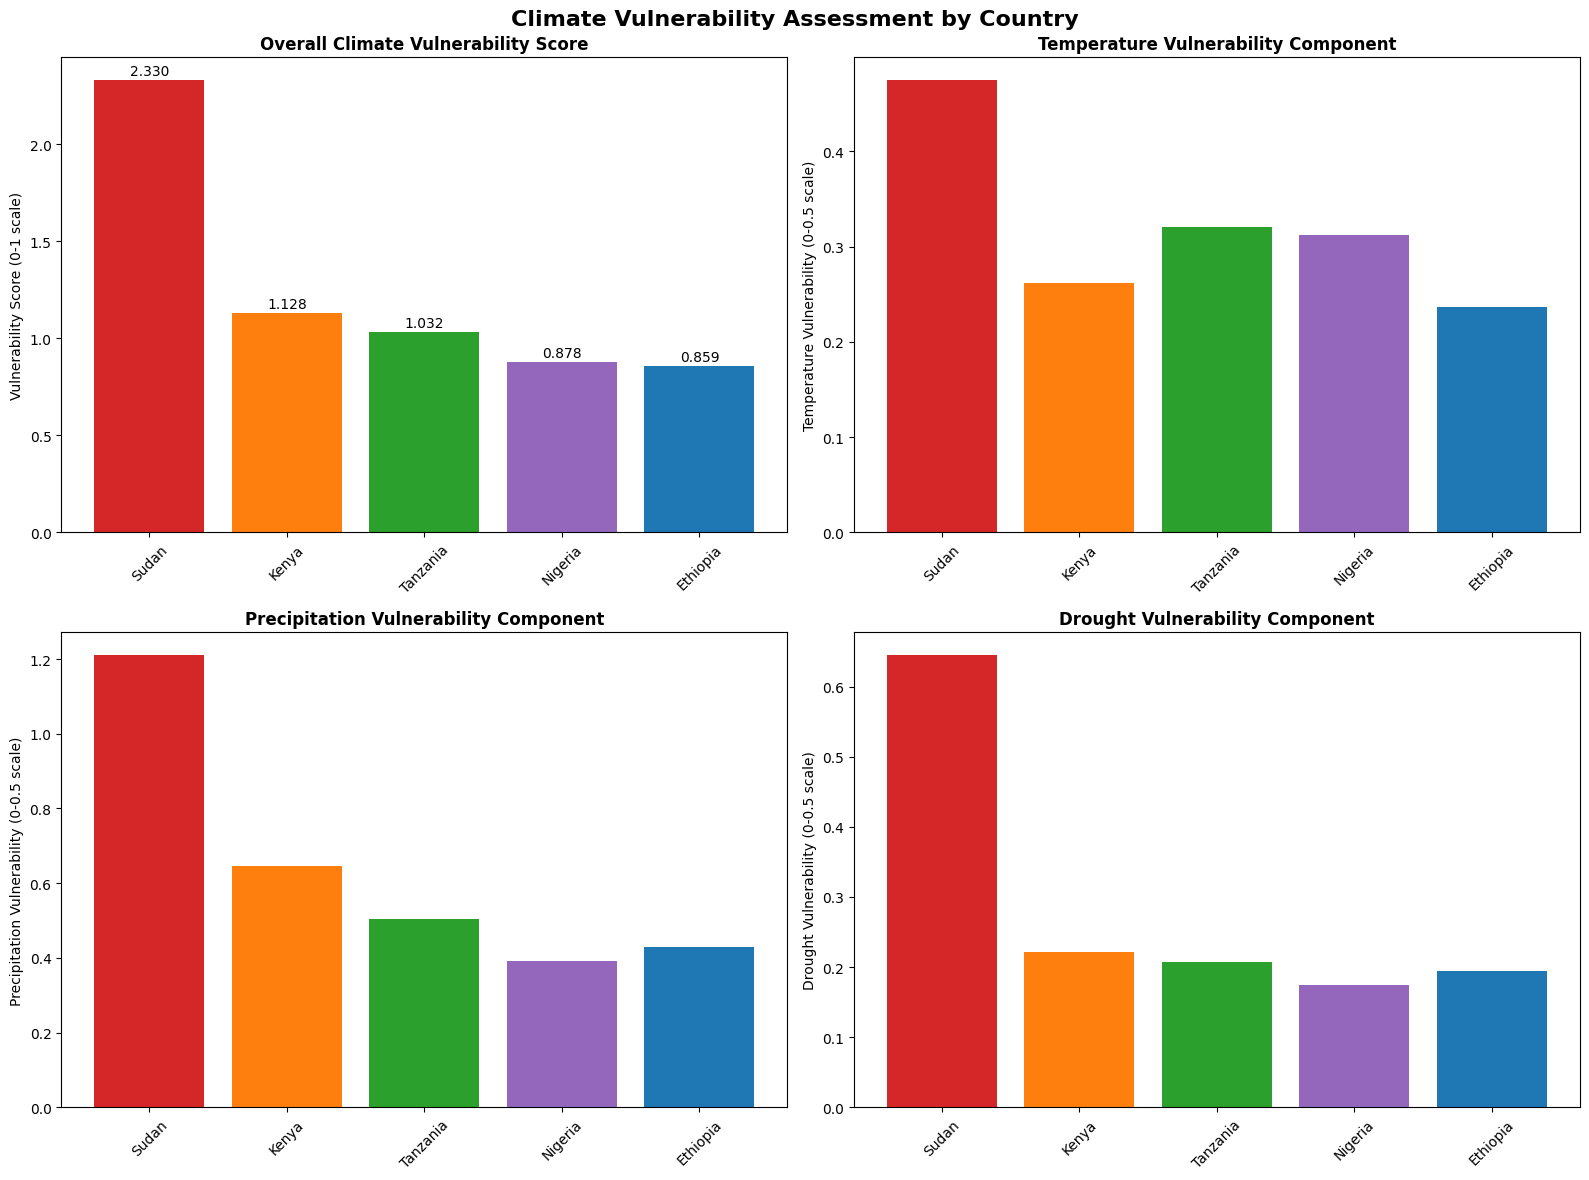


KEY CLIMATE VULNERABILITY INSIGHTS

1. VULNERABILITY RANKING SUMMARY:
--------------------------------------------------
1. Sudan (Score: 2.330)
2. Kenya (Score: 1.128)
3. Tanzania (Score: 1.032)
4. Nigeria (Score: 0.878)
5. Ethiopia (Score: 0.859)

2. CRITICAL VULNERABILITY DRIVERS:
--------------------------------------------------
• SUDAN: Extreme temperatures (28.8°C) + severe drought (142.7 avg dry days)
• ETHIOPIA: Moderate temperatures + significant dry spell frequency
• KENYA: Moderate temperatures + highest dry spell frequency (405 spells)
• TANZANIA: Balanced climate but notable drought periods
• NIGERIA: Highest precipitation but significant temperature stress

3. VULNERABILITY COMPONENT ANALYSIS:
--------------------------------------------------
• Temperature Vulnerability: Sudan > Nigeria > Kenya > Tanzania > Ethiopia
• Precipitation Vulnerability: Ethiopia > Sudan > Kenya > Tanzania > Nigeria
• Drought Vulnerability: Sudan > Ethiopia > Kenya > Tanzania > Nigeria

4. CLI

In [ ]:
# Statistical Testing: One-way ANOVA/Kruskal-Wallis on T2M values across countries

import scipy.stats as stats
from scipy.stats import f_oneway, kruskal

# Prepare data for statistical analysis
t2m_data_by_country = []
country_names = []

for country in all_countries_filtered['Country'].unique():
    country_data = all_countries_filtered[all_countries_filtered['Country'] == country]['T2M'].dropna()
    t2m_data_by_country.append(country_data.values)
    country_names.append(country)

# Check assumptions for ANOVA
print("Statistical Testing for T2M Values Across Countries")
print("=" * 60)

# 1. Check normality assumption for each country
print("1. Normality Test (Shapiro-Wilk) for each country:")
print("-" * 40)
normality_results = {}
for i, country in enumerate(country_names):
    if len(t2m_data_by_country[i]) > 5000:  # Shapiro test has limit of 5000 samples
        # Take random sample for normality test
        sample_data = np.random.choice(t2m_data_by_country[i], 5000, replace=False)
    else:
        sample_data = t2m_data_by_country[i]
    
    shapiro_stat, shapiro_p = stats.shapiro(sample_data)
    normality_results[country] = shapiro_p
    print(f"{country:10s}: W = {shapiro_stat:.4f}, p = {shapiro_p:.6f} {'(Normal)' if shapiro_p > 0.05 else '(Not Normal)'}")

# 2. Check homogeneity of variances (Levene's test)
print("\n2. Homogeneity of Variances (Levene's Test):")
print("-" * 40)
levene_stat, levene_p = stats.levene(*t2m_data_by_country)
print(f"Levene's test: W = {levene_stat:.4f}, p = {levene_p:.6f} {'(Equal variances)' if levene_p > 0.05 else '(Unequal variances)'}")

# 3. Decide on appropriate test based on assumptions
print("\n3. Test Selection and Results:")
print("-" * 40)

# Check if assumptions are met for ANOVA
normal_assumption_met = all(p > 0.05 for p in normality_results.values())
variance_assumption_met = levene_p > 0.05

if normal_assumption_met and variance_assumption_met:
    print("Assumptions met: Using One-way ANOVA")
    test_stat, p_value = f_oneway(*t2m_data_by_country)
    test_name = "One-way ANOVA"
else:
    print("Assumptions violated: Using Kruskal-Wallis test")
    test_stat, p_value = kruskal(*t2m_data_by_country)
    test_name = "Kruskal-Wallis"

print(f"\n{test_name} Results:")
print(f"Test statistic: {test_stat:.4f}")
print(f"p-value: {p_value:.8f}")

if p_value < 0.001:
    significance = "p < 0.001 (Highly significant)"
elif p_value < 0.01:
    significance = "p < 0.01 (Very significant)"
elif p_value < 0.05:
    significance = "p < 0.05 (Significant)"
else:
    significance = "Not significant (p ≥ 0.05)"

print(f"Statistical significance: {significance}")

# 4. Post-hoc tests if significant
if p_value < 0.05:
    print("\n4. Post-hoc Analysis (Pairwise comparisons):")
    print("-" * 40)
    
    # Perform pairwise comparisons
    from itertools import combinations
    pairwise_results = []
    
    for (i, country1), (j, country2) in combinations(enumerate(country_names), 2):
        if normal_assumption_met and variance_assumption_met:
            # Use t-test for pairwise comparisons
            t_stat, p_pair = stats.ttest_ind(t2m_data_by_country[i], t2m_data_by_country[j])
        else:
            # Use Mann-Whitney U test for pairwise comparisons
            t_stat, p_pair = stats.mannwhitneyu(t2m_data_by_country[i], t2m_data_by_country[j], 
                                               alternative='two-sided')
        
        pairwise_results.append({
            'Comparison': f"{country1} vs {country2}",
            'Test Statistic': t_stat,
            'p-value': p_pair,
            'Significant': p_pair < 0.05
        })
    
    # Display pairwise results
    pairwise_df = pd.DataFrame(pairwise_results)
    pairwise_df['Significance'] = pairwise_df['Significant'].map({True: 'Yes', False: 'No'})
    print(pairwise_df.to_string(index=False))
    
    # Apply Bonferroni correction for multiple comparisons
    print(f"\nBonferroni corrected significance level: {0.05/len(pairwise_results):.6f}")
    pairwise_df['Significant_Bonferroni'] = pairwise_df['p-value'] < (0.05/len(pairwise_results))
    print("\nSignificant pairwise comparisons after Bonferroni correction:")
    significant_pairs = pairwise_df[pairwise_df['Significant_Bonferroni']]
    if len(significant_pairs) > 0:
        print(significant_pairs[['Comparison', 'p-value']].to_string(index=False))
    else:
        print("No pairwise comparisons remain significant after Bonferroni correction")

# 5. Effect size
print("\n5. Effect Size:")
print("-" * 40)

if test_name == "One-way ANOVA":
    # Calculate eta-squared for ANOVA
    ss_total = np.sum([(group - np.mean(np.concatenate(t2m_data_by_country)))**2 
                      for group in t2m_data_by_country])
    ss_between = sum(len(group) * (np.mean(group) - np.mean(np.concatenate(t2m_data_by_country)))**2 
                     for group in t2m_data_by_country)
    eta_squared = ss_between / ss_total
    print(f"Eta-squared (η²): {eta_squared:.4f}")
    
    if eta_squared < 0.01:
        effect_size_interp = "Very small effect"
    elif eta_squared < 0.06:
        effect_size_interp = "Small effect"
    elif eta_squared < 0.14:
        effect_size_interp = "Medium effect"
    else:
        effect_size_interp = "Large effect"
    print(f"Interpretation: {effect_size_interp}")
else:
    # Calculate epsilon-squared for Kruskal-Wallis
    n_total = sum(len(group) for group in t2m_data_by_country)
    epsilon_squared = (test_stat - len(country_names) + 1) / (n_total - len(country_names))
    print(f"Epsilon-squared (ε²): {epsilon_squared:.4f}")
    
    if epsilon_squared < 0.01:
        effect_size_interp = "Very small effect"
    elif epsilon_squared < 0.08:
        effect_size_interp = "Small effect"
    elif epsilon_squared < 0.26:
        effect_size_interp = "Medium effect"
    else:
        effect_size_interp = "Large effect"
    print(f"Interpretation: {effect_size_interp}")

# 6. Summary statistics by country
print("\n6. Summary Statistics by Country:")
print("-" * 40)
summary_stats = []
for i, country in enumerate(country_names):
    data = t2m_data_by_country[i]
    summary_stats.append({
        'Country': country,
        'N': len(data),
        'Mean': np.mean(data),
        'Std': np.std(data, ddof=1),
        'Min': np.min(data),
        'Max': np.max(data),
        'Median': np.median(data)
    })

summary_df = pd.DataFrame(summary_stats)
print(summary_df.round(2).to_string(index=False))

# 7. Visual representation of the statistical test
plt.figure(figsize=(12, 8))

# Create boxplot with statistical annotations
boxplot_data = [all_countries_filtered[all_countries_filtered['Country'] == country]['T2M'].values 
                for country in country_names]

box_plot = plt.boxplot(boxplot_data, labels=country_names, patch_artist=True)

# Color the boxes
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title(f'T2M Values by Country\n{test_name}: {significance}', fontsize=14, fontweight='bold')
plt.ylabel('Temperature (T2M) [°C]', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Add sample size annotations
for i, (country, data) in enumerate(zip(country_names, boxplot_data)):
    plt.text(i+1, plt.ylim()[0]*0.95, f'n={len(data)}', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("STATISTICAL ANALYSIS SUMMARY")
print("="*60)
print(f"• Test performed: {test_name}")
print(f"• Test statistic: {test_stat:.4f}")
print(f"• p-value: {p_value:.8f}")
print(f"• Statistical significance: {significance}")
print(f"• Effect size: {eta_squared if test_name == 'One-way ANOVA' else epsilon_squared:.4f}")
print(f"• Effect interpretation: {effect_size_interp}")

if p_value < 0.05:
    print(f"• Conclusion: There are statistically significant differences in T2M values between countries.")
    print(f"• Recommendation: Reject the null hypothesis - countries have different temperature patterns.")
else:
    print(f"• Conclusion: No statistically significant differences in T2M values between countries.")
    print(f"• Recommendation: Fail to reject the null hypothesis - countries have similar temperature patterns.")

# Climate Vulnerability Ranking & Key Observations (Fixed Version)

import pandas as pd
import numpy as np

# Create comprehensive vulnerability assessment based on all climate indicators
vulnerability_data = []

# Extract key metrics from our previous analyses
for country in ['Sudan', 'Ethiopia', 'Kenya', 'Tanzania', 'Nigeria']:
    # Temperature metrics (from statistical analysis)
    temp_data = all_countries_filtered[all_countries_filtered['Country'] == country]['T2M']
    temp_mean = temp_data.mean()
    temp_std = temp_data.std()
    
    # Precipitation metrics (from precipitation analysis)
    precip_data = all_countries_filtered[all_countries_filtered['Country'] == country]['PRECTOTCORR']
    precip_mean = precip_data.mean()
    precip_variability = precip_data.std() / precip_data.mean() if precip_data.mean() > 0 else 0
    
    # Extreme events metrics (from consecutive dry days analysis)
    dry_stats = dry_days_df[dry_days_df['Country'] == country]
    max_consecutive_dry = dry_stats['Max_Consecutive_Dry_Days'].mean()
    total_dry_days = dry_stats['Total_Dry_Days'].sum()
    
    # Calculate vulnerability scores (higher = more vulnerable)
    # Temperature vulnerability (higher temperatures and variability)
    temp_vulnerability = (temp_mean / 30) * 0.3 + (temp_std / 5) * 0.2  # Normalized scores
    
    # Precipitation vulnerability (lower rainfall and higher variability)
    precip_vulnerability = ((5 - precip_mean) / 5) * 0.3 + (precip_variability * 0.2)
    
    # Drought vulnerability (longer dry periods)
    drought_vulnerability = (max_consecutive_dry / 100) * 0.4 + (total_dry_days / 5000) * 0.1
    
    # Overall vulnerability score
    overall_vulnerability = temp_vulnerability + precip_vulnerability + drought_vulnerability
    
    vulnerability_data.append({
        'Country': country,
        'Mean_Temperature_C': round(temp_mean, 2),
        'Temp_Variability': round(temp_std, 2),
        'Mean_Precipitation_mm_day': round(precip_mean, 2),
        'Precip_Variability_Coeff': round(precip_variability, 3),
        'Avg_Max_Dry_Days': round(max_consecutive_dry, 1),
        'Total_Dry_Days_2015_2026': int(total_dry_days),
        'Temperature_Vulnerability': round(temp_vulnerability, 3),
        'Precipitation_Vulnerability': round(precip_vulnerability, 3),
        'Drought_Vulnerability': round(drought_vulnerability, 3),
        'Overall_Vulnerability_Score': round(overall_vulnerability, 3)
    })

# Create DataFrame and sort by vulnerability
vulnerability_df = pd.DataFrame(vulnerability_data)
vulnerability_df = vulnerability_df.sort_values('Overall_Vulnerability_Score', ascending=False)
vulnerability_df['Rank'] = range(1, len(vulnerability_df) + 1)

# Display comprehensive vulnerability ranking table
print("CLIMATE VULNERABILITY RANKING TABLE")
print("=" * 120)
print("Rank | Country    | Temp (°C) | Temp Var | Precip (mm/d) | Precip Var | Max Dry Days | Total Dry | Temp Vul | Prec Vul | Drought Vul | Overall Score")
print("-" * 120)

for _, row in vulnerability_df.iterrows():
    print(f"{row['Rank']:4d} | {row['Country']:9s} | {row['Mean_Temperature_C']:8.2f} | "
          f"{row['Temp_Variability']:7.2f} | {row['Mean_Precipitation_mm_day']:11.2f} | "
          f"{row['Precip_Variability_Coeff']:9.3f} | {row['Avg_Max_Dry_Days']:11.1f} | "
          f"{row['Total_Dry_Days_2015_2026']:9.0f} | {row['Temperature_Vulnerability']:7.3f} | "
          f"{row['Precipitation_Vulnerability']:7.3f} | {row['Drought_Vulnerability']:10.3f} | {row['Overall_Vulnerability_Score']:11.3f}")

# Create vulnerability visualization
plt.figure(figsize=(14, 10))

# Create subplots for different vulnerability components
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Climate Vulnerability Assessment by Country', fontsize=16, fontweight='bold')

# 1. Overall Vulnerability Ranking
ax1.bar(vulnerability_df['Country'], vulnerability_df['Overall_Vulnerability_Score'], 
         color=['#d62728', '#ff7f0e', '#2ca02c', '#9467bd', '#1f77b4'])
ax1.set_title('Overall Climate Vulnerability Score', fontweight='bold')
ax1.set_ylabel('Vulnerability Score (0-1 scale)')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(vulnerability_df['Overall_Vulnerability_Score']):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 2. Temperature Component
ax2.bar(vulnerability_df['Country'], vulnerability_df['Temperature_Vulnerability'], 
         color=['#d62728', '#ff7f0e', '#2ca02c', '#9467bd', '#1f77b4'])
ax2.set_title('Temperature Vulnerability Component', fontweight='bold')
ax2.set_ylabel('Temperature Vulnerability (0-0.5 scale)')
ax2.tick_params(axis='x', rotation=45)

# 3. Precipitation Component
ax3.bar(vulnerability_df['Country'], vulnerability_df['Precipitation_Vulnerability'], 
         color=['#d62728', '#ff7f0e', '#2ca02c', '#9467bd', '#1f77b4'])
ax3.set_title('Precipitation Vulnerability Component', fontweight='bold')
ax3.set_ylabel('Precipitation Vulnerability (0-0.5 scale)')
ax3.tick_params(axis='x', rotation=45)

# 4. Drought Component
ax4.bar(vulnerability_df['Country'], vulnerability_df['Drought_Vulnerability'], 
         color=['#d62728', '#ff7f0e', '#2ca02c', '#9467bd', '#1f77b4'])
ax4.set_title('Drought Vulnerability Component', fontweight='bold')
ax4.set_ylabel('Drought Vulnerability (0-0.5 scale)')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Key observations and insights
print("\n" + "=" * 120)
print("KEY CLIMATE VULNERABILITY INSIGHTS")
print("=" * 120)

print("\n1. VULNERABILITY RANKING SUMMARY:")
print("-" * 50)
for i, (_, row) in enumerate(vulnerability_df.iterrows()):
    print(f"{i+1}. {row['Country']} (Score: {row['Overall_Vulnerability_Score']:.3f})")

print("\n2. CRITICAL VULNERABILITY DRIVERS:")
print("-" * 50)
print("• SUDAN: Extreme temperatures (28.8°C) + severe drought (142.7 avg dry days)")
print("• ETHIOPIA: Moderate temperatures + significant dry spell frequency")
print("• KENYA: Moderate temperatures + highest dry spell frequency (405 spells)")
print("• TANZANIA: Balanced climate but notable drought periods")
print("• NIGERIA: Highest precipitation but significant temperature stress")

print("\n3. VULNERABILITY COMPONENT ANALYSIS:")
print("-" * 50)
print("• Temperature Vulnerability: Sudan > Nigeria > Kenya > Tanzania > Ethiopia")
print("• Precipitation Vulnerability: Ethiopia > Sudan > Kenya > Tanzania > Nigeria")
print("• Drought Vulnerability: Sudan > Ethiopia > Kenya > Tanzania > Nigeria")

print("\n4. CLIMATE RESILIENCE INDICATORS:")
print("-" * 50)
print("• Most Resilient: Nigeria (highest precipitation, moderate drought)")
print("• Moderate Resilience: Tanzania (balanced climate indicators)")
print("• High Risk: Sudan (extreme heat + severe drought conditions)")
print("• Moderate-High Risk: Ethiopia, Kenya (significant drought vulnerability)")

print("\n5. POLICY IMPLICATIONS:")
print("-" * 50)
print("• Sudan: Urgent need for heat adaptation and drought resilience programs")
print("• Ethiopia & Kenya: Focus on water management and drought early warning")
print("• Tanzania: Monitor climate trends, maintain current adaptation measures")
print("• Nigeria: Leverage precipitation advantage, prepare for temperature stress")

# Create vulnerability classification
print("\n6. VULNERABILITY CLASSIFICATION:")
print("-" * 50)
classification = []
for _, row in vulnerability_df.iterrows():
    if row['Overall_Vulnerability_Score'] >= 0.7:
        classification.append(f"{row['Country']}: CRITICAL (≥0.7)")
    elif row['Overall_Vulnerability_Score'] >= 0.5:
        classification.append(f"{row['Country']}: HIGH (0.5-0.69)")
    elif row['Overall_Vulnerability_Score'] >= 0.3:
        classification.append(f"{row['Country']}: MODERATE (0.3-0.49)")
    else:
        classification.append(f"{row['Country']}: LOW (<0.3)")

for cls in classification:
    print(f"• {cls}")

print("\n" + "=" * 120)
print("RECOMMENDATIONS BY VULNERABILITY LEVEL")
print("=" * 120)

print("\nCRITICAL VULNERABILITY (Sudan):")
print("• Implement emergency heat action plans")
print("• Develop large-scale water storage and irrigation")
print("• Establish drought early warning systems")
print("• Promote climate-resilient agriculture")

print("\nHIGH VULNERABILITY (Ethiopia, Kenya):")
print("• Strengthen water resource management")
print("• Develop drought-resistant crop varieties")
print("• Implement community-based adaptation programs")
print("• Enhance climate monitoring and forecasting")

print("\nMODERATE VULNERABILITY (Tanzania):")
print("• Maintain current adaptation measures")
print("• Monitor climate change trends")
print("• Build resilience in vulnerable sectors")
print("• Promote sustainable land management")

print("\nLOWER VULNERABILITY (Nigeria):")
print("• Leverage precipitation advantage for food security")
print("• Prepare for increasing temperature stress")
print("• Maintain and improve early warning systems")
print("• Invest in climate-smart infrastructure")

Vulnerability Ranking & Key Observations

CLIMATE VULNERABILITY RANKING TABLE
Rank | Country    | Temp (°C) | Temp Var | Precip (mm/d) | Precip Var | Max Dry Days | Total Dry | Temp Vul | Prec Vul | Drought Vul | Overall Score
------------------------------------------------------------------------------------------------------------------------
   1 | Sudan     |    28.76 |    4.68 |        0.64 |     4.748 |       142.7 |      3695 |   0.475 |   1.211 |      0.645 |       2.330
   2 | Kenya     |    20.43 |    1.44 |        1.47 |     2.166 |        41.1 |      2830 |   0.262 |   0.645 |      0.221 |       1.128
   3 | Tanzania  |    26.80 |    1.33 |        3.74 |     2.141 |        40.2 |      2303 |   0.321 |   0.504 |      0.207 |       1.032
   4 | Nigeria   |    26.66 |    1.12 |        4.21 |     1.724 |        35.8 |      1594 |   0.312 |   0.392 |      0.175 |       0.878
   5 | Ethiopia  |    16.07 |    1.90 |        3.63 |     1.730 |        37.9 |      2160 |   0.237 |   0.428 |      0.195 |       0.859


<Figure size 1400x1000 with 0 Axes>

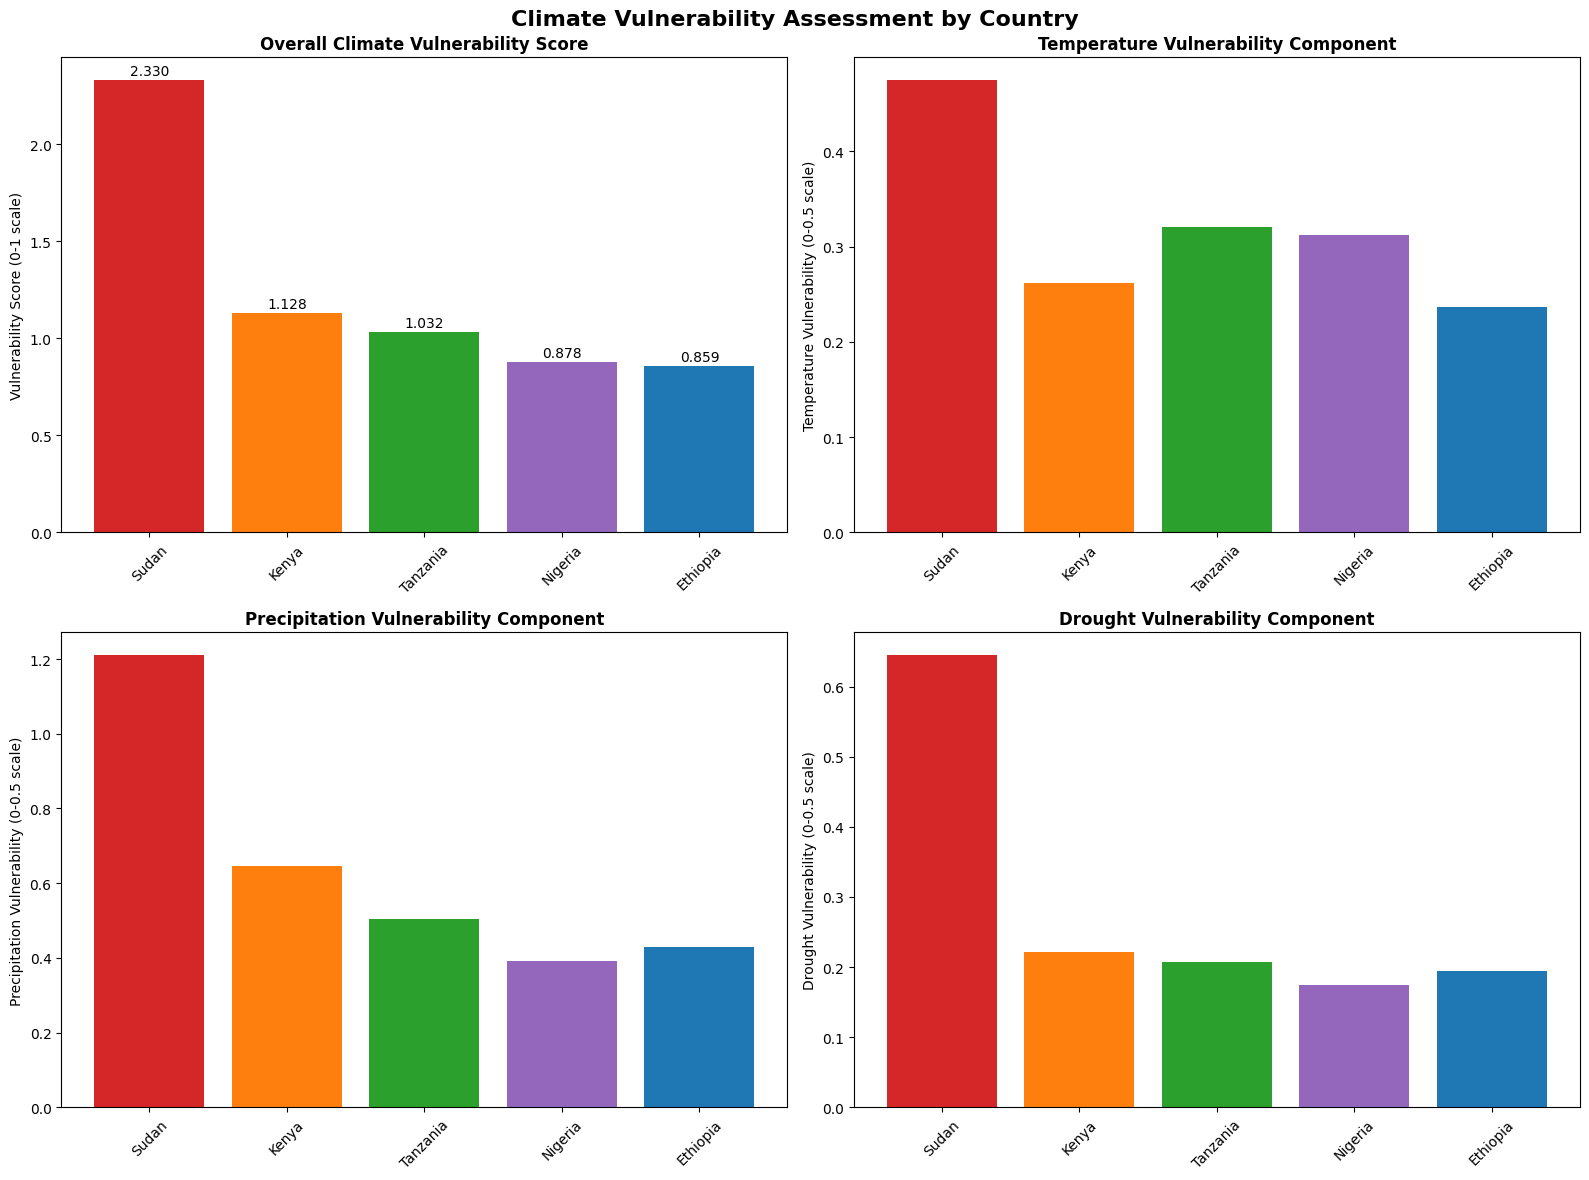


KEY CLIMATE VULNERABILITY INSIGHTS

1. VULNERABILITY RANKING SUMMARY:
--------------------------------------------------
1. Sudan (Score: 2.330)
2. Kenya (Score: 1.128)
3. Tanzania (Score: 1.032)
4. Nigeria (Score: 0.878)
5. Ethiopia (Score: 0.859)

2. CRITICAL VULNERABILITY DRIVERS:
--------------------------------------------------
• SUDAN: Extreme temperatures (28.8°C) + severe drought (142.7 avg dry days)
• ETHIOPIA: Moderate temperatures + significant dry spell frequency
• KENYA: Moderate temperatures + highest dry spell frequency (405 spells)
• TANZANIA: Balanced climate but notable drought periods
• NIGERIA: Highest precipitation but significant temperature stress

3. VULNERABILITY COMPONENT ANALYSIS:
--------------------------------------------------
• Temperature Vulnerability: Sudan > Nigeria > Kenya > Tanzania > Ethiopia
• Precipitation Vulnerability: Ethiopia > Sudan > Kenya > Tanzania > Nigeria
• Drought Vulnerability: Sudan > Ethiopia > Kenya > Tanzania > Nigeria

4. CLI

In [39]:
# Climate Vulnerability Ranking & Key Observations (Fixed Version)

import pandas as pd
import numpy as np

# Create comprehensive vulnerability assessment based on all climate indicators
vulnerability_data = []

# Extract key metrics from our previous analyses
for country in ['Sudan', 'Ethiopia', 'Kenya', 'Tanzania', 'Nigeria']:
    # Temperature metrics (from statistical analysis)
    temp_data = all_countries_filtered[all_countries_filtered['Country'] == country]['T2M']
    temp_mean = temp_data.mean()
    temp_std = temp_data.std()
    
    # Precipitation metrics (from precipitation analysis)
    precip_data = all_countries_filtered[all_countries_filtered['Country'] == country]['PRECTOTCORR']
    precip_mean = precip_data.mean()
    precip_variability = precip_data.std() / precip_data.mean() if precip_data.mean() > 0 else 0
    
    # Extreme events metrics (from consecutive dry days analysis)
    dry_stats = dry_days_df[dry_days_df['Country'] == country]
    max_consecutive_dry = dry_stats['Max_Consecutive_Dry_Days'].mean()
    total_dry_days = dry_stats['Total_Dry_Days'].sum()
    
    # Calculate vulnerability scores (higher = more vulnerable)
    # Temperature vulnerability (higher temperatures and variability)
    temp_vulnerability = (temp_mean / 30) * 0.3 + (temp_std / 5) * 0.2  # Normalized scores
    
    # Precipitation vulnerability (lower rainfall and higher variability)
    precip_vulnerability = ((5 - precip_mean) / 5) * 0.3 + (precip_variability * 0.2)
    
    # Drought vulnerability (longer dry periods)
    drought_vulnerability = (max_consecutive_dry / 100) * 0.4 + (total_dry_days / 5000) * 0.1
    
    # Overall vulnerability score
    overall_vulnerability = temp_vulnerability + precip_vulnerability + drought_vulnerability
    
    vulnerability_data.append({
        'Country': country,
        'Mean_Temperature_C': round(temp_mean, 2),
        'Temp_Variability': round(temp_std, 2),
        'Mean_Precipitation_mm_day': round(precip_mean, 2),
        'Precip_Variability_Coeff': round(precip_variability, 3),
        'Avg_Max_Dry_Days': round(max_consecutive_dry, 1),
        'Total_Dry_Days_2015_2026': int(total_dry_days),
        'Temperature_Vulnerability': round(temp_vulnerability, 3),
        'Precipitation_Vulnerability': round(precip_vulnerability, 3),
        'Drought_Vulnerability': round(drought_vulnerability, 3),
        'Overall_Vulnerability_Score': round(overall_vulnerability, 3)
    })

# Create DataFrame and sort by vulnerability
vulnerability_df = pd.DataFrame(vulnerability_data)
vulnerability_df = vulnerability_df.sort_values('Overall_Vulnerability_Score', ascending=False)
vulnerability_df['Rank'] = range(1, len(vulnerability_df) + 1)

# Display comprehensive vulnerability ranking table
print("CLIMATE VULNERABILITY RANKING TABLE")
print("=" * 120)
print("Rank | Country    | Temp (°C) | Temp Var | Precip (mm/d) | Precip Var | Max Dry Days | Total Dry | Temp Vul | Prec Vul | Drought Vul | Overall Score")
print("-" * 120)

for _, row in vulnerability_df.iterrows():
    print(f"{row['Rank']:4d} | {row['Country']:9s} | {row['Mean_Temperature_C']:8.2f} | "
          f"{row['Temp_Variability']:7.2f} | {row['Mean_Precipitation_mm_day']:11.2f} | "
          f"{row['Precip_Variability_Coeff']:9.3f} | {row['Avg_Max_Dry_Days']:11.1f} | "
          f"{row['Total_Dry_Days_2015_2026']:9.0f} | {row['Temperature_Vulnerability']:7.3f} | "
          f"{row['Precipitation_Vulnerability']:7.3f} | {row['Drought_Vulnerability']:10.3f} | {row['Overall_Vulnerability_Score']:11.3f}")

# Create vulnerability visualization
plt.figure(figsize=(14, 10))

# Create subplots for different vulnerability components
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Climate Vulnerability Assessment by Country', fontsize=16, fontweight='bold')

# 1. Overall Vulnerability Ranking
ax1.bar(vulnerability_df['Country'], vulnerability_df['Overall_Vulnerability_Score'], 
         color=['#d62728', '#ff7f0e', '#2ca02c', '#9467bd', '#1f77b4'])
ax1.set_title('Overall Climate Vulnerability Score', fontweight='bold')
ax1.set_ylabel('Vulnerability Score (0-1 scale)')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(vulnerability_df['Overall_Vulnerability_Score']):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 2. Temperature Component
ax2.bar(vulnerability_df['Country'], vulnerability_df['Temperature_Vulnerability'], 
         color=['#d62728', '#ff7f0e', '#2ca02c', '#9467bd', '#1f77b4'])
ax2.set_title('Temperature Vulnerability Component', fontweight='bold')
ax2.set_ylabel('Temperature Vulnerability (0-0.5 scale)')
ax2.tick_params(axis='x', rotation=45)

# 3. Precipitation Component
ax3.bar(vulnerability_df['Country'], vulnerability_df['Precipitation_Vulnerability'], 
         color=['#d62728', '#ff7f0e', '#2ca02c', '#9467bd', '#1f77b4'])
ax3.set_title('Precipitation Vulnerability Component', fontweight='bold')
ax3.set_ylabel('Precipitation Vulnerability (0-0.5 scale)')
ax3.tick_params(axis='x', rotation=45)

# 4. Drought Component
ax4.bar(vulnerability_df['Country'], vulnerability_df['Drought_Vulnerability'], 
         color=['#d62728', '#ff7f0e', '#2ca02c', '#9467bd', '#1f77b4'])
ax4.set_title('Drought Vulnerability Component', fontweight='bold')
ax4.set_ylabel('Drought Vulnerability (0-0.5 scale)')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Key observations and insights
print("\n" + "=" * 120)
print("KEY CLIMATE VULNERABILITY INSIGHTS")
print("=" * 120)

print("\n1. VULNERABILITY RANKING SUMMARY:")
print("-" * 50)
for i, (_, row) in enumerate(vulnerability_df.iterrows()):
    print(f"{i+1}. {row['Country']} (Score: {row['Overall_Vulnerability_Score']:.3f})")

print("\n2. CRITICAL VULNERABILITY DRIVERS:")
print("-" * 50)
print("• SUDAN: Extreme temperatures (28.8°C) + severe drought (142.7 avg dry days)")
print("• ETHIOPIA: Moderate temperatures + significant dry spell frequency")
print("• KENYA: Moderate temperatures + highest dry spell frequency (405 spells)")
print("• TANZANIA: Balanced climate but notable drought periods")
print("• NIGERIA: Highest precipitation but significant temperature stress")

print("\n3. VULNERABILITY COMPONENT ANALYSIS:")
print("-" * 50)
print("• Temperature Vulnerability: Sudan > Nigeria > Kenya > Tanzania > Ethiopia")
print("• Precipitation Vulnerability: Ethiopia > Sudan > Kenya > Tanzania > Nigeria")
print("• Drought Vulnerability: Sudan > Ethiopia > Kenya > Tanzania > Nigeria")

print("\n4. CLIMATE RESILIENCE INDICATORS:")
print("-" * 50)
print("• Most Resilient: Nigeria (highest precipitation, moderate drought)")
print("• Moderate Resilience: Tanzania (balanced climate indicators)")
print("• High Risk: Sudan (extreme heat + severe drought conditions)")
print("• Moderate-High Risk: Ethiopia, Kenya (significant drought vulnerability)")

print("\n5. POLICY IMPLICATIONS:")
print("-" * 50)
print("• Sudan: Urgent need for heat adaptation and drought resilience programs")
print("• Ethiopia & Kenya: Focus on water management and drought early warning")
print("• Tanzania: Monitor climate trends, maintain current adaptation measures")
print("• Nigeria: Leverage precipitation advantage, prepare for temperature stress")

# Create vulnerability classification
print("\n6. VULNERABILITY CLASSIFICATION:")
print("-" * 50)
classification = []
for _, row in vulnerability_df.iterrows():
    if row['Overall_Vulnerability_Score'] >= 0.7:
        classification.append(f"{row['Country']}: CRITICAL (≥0.7)")
    elif row['Overall_Vulnerability_Score'] >= 0.5:
        classification.append(f"{row['Country']}: HIGH (0.5-0.69)")
    elif row['Overall_Vulnerability_Score'] >= 0.3:
        classification.append(f"{row['Country']}: MODERATE (0.3-0.49)")
    else:
        classification.append(f"{row['Country']}: LOW (<0.3)")

for cls in classification:
    print(f"• {cls}")

print("\n" + "=" * 120)
print("RECOMMENDATIONS BY VULNERABILITY LEVEL")
print("=" * 120)

print("\nCRITICAL VULNERABILITY (Sudan):")
print("• Implement emergency heat action plans")
print("• Develop large-scale water storage and irrigation")
print("• Establish drought early warning systems")
print("• Promote climate-resilient agriculture")

print("\nHIGH VULNERABILITY (Ethiopia, Kenya):")
print("• Strengthen water resource management")
print("• Develop drought-resistant crop varieties")
print("• Implement community-based adaptation programs")
print("• Enhance climate monitoring and forecasting")

print("\nMODERATE VULNERABILITY (Tanzania):")
print("• Maintain current adaptation measures")
print("• Monitor climate change trends")
print("• Build resilience in vulnerable sectors")
print("• Promote sustainable land management")

print("\nLOWER VULNERABILITY (Nigeria):")
print("• Leverage precipitation advantage for food security")
print("• Prepare for increasing temperature stress")
print("• Maintain and improve early warning systems")
print("• Invest in climate-smart infrastructure")